In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import os

# Main libraries
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# We will use Polars for data manipulation
import polars as pl

from config import DATA_PATH
from data import SPECIES_MAPPING

# Loading data

Hereafter we load the data to perform our spatial analysis.

In [30]:
df = (
    pl.read_parquet(
        # os.path.join(DATA_PATH, "tidy", "cpf-level2_growth-periods_with-cc.parquet")
        os.path.join(DATA_PATH, "tidy", "cpf-level2_cleaned.parquet")
    )
    .with_columns(species=pl.col("specie").cast(pl.Utf8).replace(SPECIES_MAPPING))
    .filter(pl.col("species").is_in(["beech", "spruce", "pine", "oak"]))
)

var_df = df.select(
    "plot_id",
    pl.col("survey_year").alias("year"),
    "plot_latitude",
    "plot_longitude",
    "growth_rate_rel",
    "species",
)

df.select(pl.col("species").unique()).to_series().to_list()

['pine', 'oak', 'beech', 'spruce']

We now plot a spatial correlogram of relative growth time-series between pairwise plots at different distances.

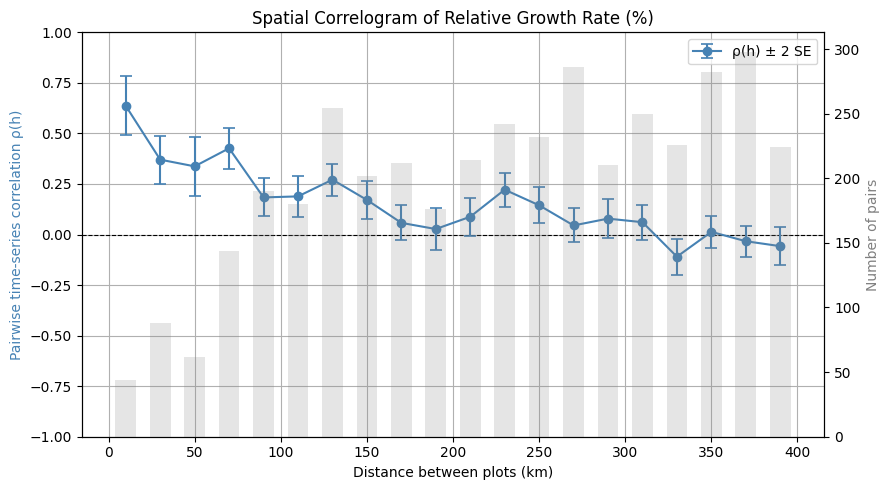

In [31]:
from scipy.stats import pearsonr
from scipy.stats import t as t_dist
from scipy.spatial.distance import pdist, squareform
from geopy.distance import geodesic

alpha = 0.05
max_dist = 400
num_bins = 20

# One mean per (plot, year) — preserves temporal structure
plot_year = var_df.group_by(["plot_id", "year"]).agg(
    (pl.mean("growth_rate_rel") * 100).alias("growth_rate_rel_mean"),
    (pl.first("plot_latitude") / 10000).alias("lat"),
    (pl.first("plot_longitude") / 10000).alias("lon"),
)

# Pivot to (plot × year) matrix
MAX_FILL_YEARS = 5  # up to a 5-year gap can be forward-filled for correlation analysis

growth_wide = plot_year.pivot(
    index="plot_id", on="year", values="growth_rate_rel_mean"
).sort("plot_id")

# Forward fill row-wise (across years), bounded by MAX_FILL_YEARS
year_cols = [c for c in growth_wide.columns if c != "plot_id"]

growth_wide = growth_wide.with_columns(
    [pl.col(c).forward_fill(limit=MAX_FILL_YEARS) for c in year_cols]
)

plot_ids = growth_wide["plot_id"].to_numpy()
Z = growth_wide.drop("plot_id").to_numpy()  # shape (n_plots, n_years)

# Coordinates per plot (stable after pivot sort)
coords = (
    plot_year.group_by("plot_id").agg(pl.first("lat"), pl.first("lon")).sort("plot_id")
)[["lat", "lon"]].to_numpy()

# Pairwise geodesic distances
dist_matrix = squareform(pdist(coords, metric=lambda u, v: geodesic(u, v).km))

# Pairwise Pearson correlations — only over years where both plots have data
n = len(plot_ids)
corr_matrix = np.full((n, n), np.nan)

for i in range(n):
    for j in range(i + 1, n):
        mask = ~np.isnan(Z[i]) & ~np.isnan(Z[j])
        if mask.sum() >= 3:
            r, _ = pearsonr(Z[i, mask], Z[j, mask])
            corr_matrix[i, j] = corr_matrix[j, i] = r

# Restrict bins to pairs with valid correlations
valid_dist = np.where(np.isnan(corr_matrix), np.nan, dist_matrix)
bins = np.linspace(0, max_dist, num_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Per-bin mean, SE, and pair count
corr_mean = np.full(len(bin_centers), np.nan)
corr_se = np.full(len(bin_centers), np.nan)
n_pairs = np.zeros(len(bin_centers), dtype=int)

for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mask = (valid_dist > lo) & (valid_dist <= hi)
    pairs = corr_matrix[mask]
    if len(pairs) >= 2:
        corr_mean[k] = pairs.mean()
        corr_se[k] = pairs.std() / np.sqrt(len(pairs))
        n_pairs[k] = len(pairs)

# Plot
fig, ax_corr = plt.subplots(figsize=(9, 5))
ax_pairs = ax_corr.twinx()

valid = ~np.isnan(corr_mean)

n_bins_tested = valid.sum()

p_values = np.full(len(bin_centers), np.nan)
for k in range(len(bin_centers)):
    if not np.isnan(corr_mean[k]) and corr_se[k] > 0 and n_pairs[k] >= 2:
        t_stat = corr_mean[k] / corr_se[k]
        p_values[k] = 2 * t_dist.sf(abs(t_stat), df=n_pairs[k] - 1)

# Bonferroni-corrected significance mask
significant = p_values < (alpha / n_bins_tested)

ax_corr.errorbar(
    bin_centers[valid],
    corr_mean[valid],
    yerr=2 * corr_se[valid],
    fmt="o-",
    color="steelblue",
    capsize=4,
    capthick=1.2,
    zorder=3,
    label="ρ(h) ± 2 SE",
)
# ax_corr.scatter(
#     bin_centers[significant],
#     corr_mean[significant],
#     s=120, zorder=4,
#     facecolors="none", edgecolors="black", linewidths=1.8,
#     label="p < 0.05 (Bonferroni)",
# )
ax_corr.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax_corr.set_ylim(-1, 1)
ax_corr.set_xlabel("Distance between plots (km)")
ax_corr.set_ylabel("Pairwise time-series correlation ρ(h)", color="steelblue")
ax_corr.set_title("Spatial Correlogram of Relative Growth Rate (%)")
ax_corr.legend(loc="upper right")
ax_corr.grid(True, zorder=0)

ax_pairs.bar(
    bin_centers,
    n_pairs,
    width=(bins[1] - bins[0]) * 0.6,
    alpha=0.2,
    color="gray",
    zorder=2,
)
ax_pairs.set_ylabel("Number of pairs", color="gray")

plt.tight_layout()
plt.show()

We also visualize mean relative growth rates across the entire ICP Level II dataset.

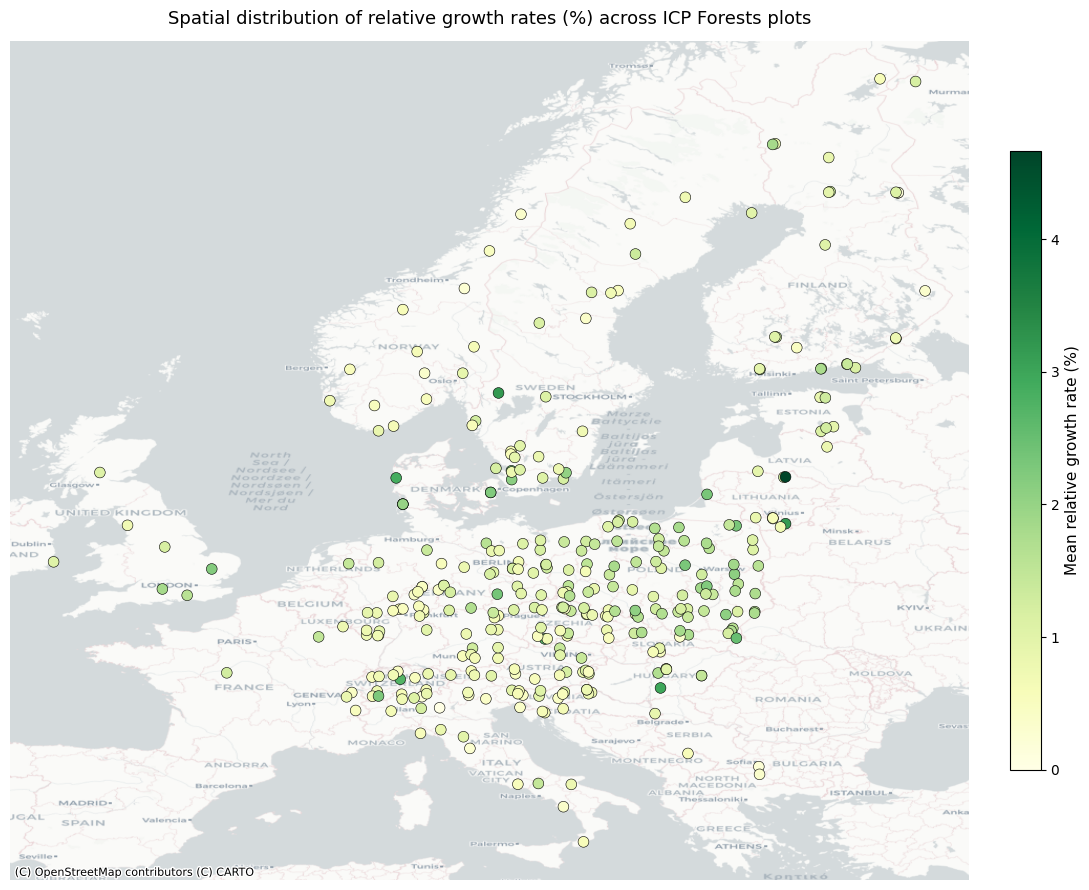

In [32]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# Aggregate mean growth rate per plot
plot_data = var_df.group_by("plot_id").agg(
    (pl.mean("growth_rate_rel") * 100).alias("growth_rate_rel_mean"),
    (pl.first("plot_latitude") / 10000).alias("lat"),
    (pl.first("plot_longitude") / 10000).alias("lon"),
)

# Convert to GeoDataFrame — reproject to Web Mercator for contextily
gdf = gpd.GeoDataFrame(
    plot_data.to_pandas(),
    geometry=[Point(xy) for xy in zip(plot_data["lon"], plot_data["lat"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

# No diverging norm needed — data is strictly positive
fig, ax = plt.subplots(figsize=(11, 9))

sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf["growth_rate_rel_mean"],
    cmap="YlGn",
    s=60,
    edgecolor="black",
    linewidth=0.4,
    zorder=3,
)

ctx.add_basemap(
    ax,
    crs=gdf.crs,
    source=ctx.providers.CartoDB.Positron,
    zoom="auto",
    zorder=1,
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Mean relative growth rate (%)", fontsize=11)

ax.set_axis_off()
ax.set_title(
    "Spatial distribution of relative growth rates (%) across ICP Forests plots",
    fontsize=13,
    pad=12,
)

plt.tight_layout()
plt.show()